# Eksperimen Operasi Dasar pada Sinyal dan Citra

**Mata Kuliah:** Pengolahan Sinyal Digital

**Topik:** Operasi penjumlahan, penggeseran, amplifikasi, superposisi, sistem linier, dan aplikasi nyata

## Daftar Isi
1. [Bagian A: Operasi pada Sinyal 1D](#bagian-a)
   - A.1 Membuat Sinyal Diskrit | A.2 Penjumlahan | A.3 Penggeseran | A.4 Amplifikasi
2. [Bagian B: Operasi pada Citra 2D](#bagian-b)
   - B.1 Membaca Citra | B.2 Penjumlahan | B.3 Translasi | B.4 Amplifikasi
3. [Bagian C: Uji Sistem Linier](#bagian-c)
   - C.1 Homogenitas | C.2 Additivitas | C.3 Perbandingan
4. [Bagian D: Analisis HOTS](#bagian-d)


## Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
print("Library imported successfully!")


Library imported successfully!


---
# Bagian A: Operasi pada Sinyal 1D


## A.1 Membuat Sinyal Diskrit
**Sinyal 1:** $x_1[n] = \sin(0.5\pi n)$ (sinusoidal)  
**Sinyal 2:** $x_2[n] = u[n-5]$ (unit step, 0 for n<5, 1 for n>=5)  
**Rentang:** $n = 0,1,2,\dots,30$

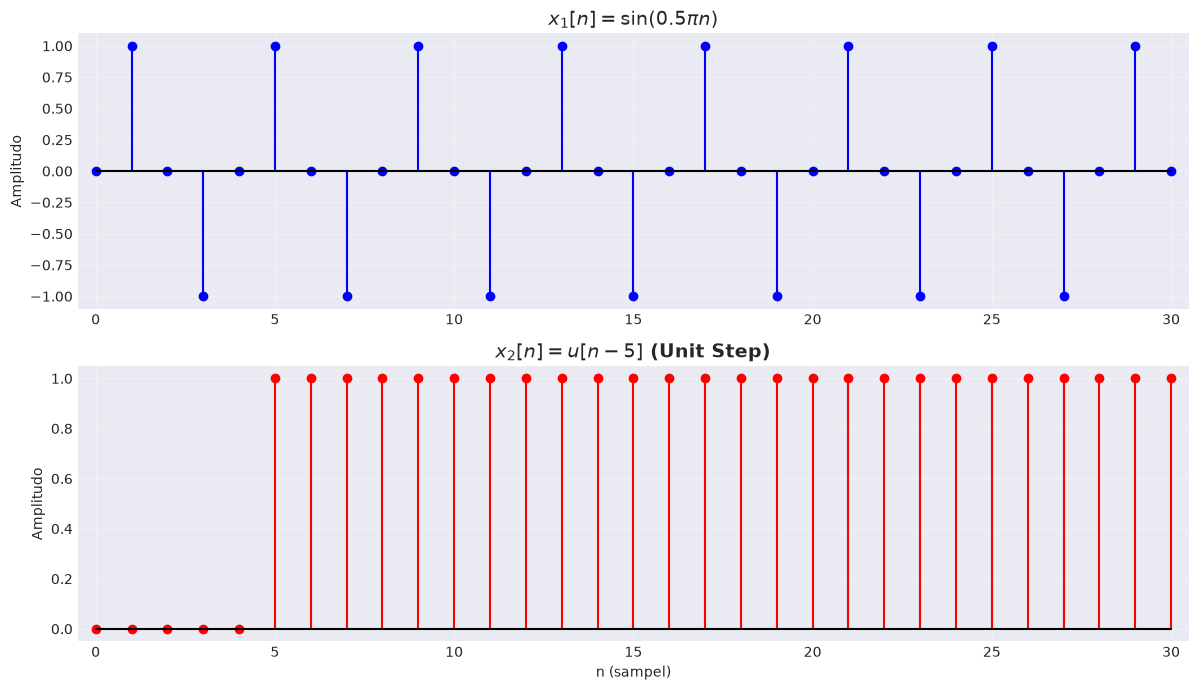

In [2]:
n = np.arange(0, 31)
x1 = np.sin(0.5 * np.pi * n)
x2 = np.where(n >= 5, 1, 0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='k-')
ax1.set_title(r'$x_1[n] = \sin(0.5\pi n)$', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amplitudo')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 30.5)

ax2.stem(n, x2, linefmt='r-', markerfmt='ro', basefmt='k-')
ax2.set_title(r'$x_2[n] = u[n-5]$ (Unit Step)', fontsize=14, fontweight='bold')
ax2.set_xlabel('n (sampel)')
ax2.set_ylabel('Amplitudo')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.5, 30.5)

plt.tight_layout()
plt.savefig('images/sinyal_x1_x2.png', dpi=100, bbox_inches='tight')
plt.show()

**Karakteristik:**  
- $x_1[n]$: sinusoidal diskrit, frekuensi $\omega = 0.5\pi$ rad/sampel, periode $N=4$  
- $x_2[n]$: aperiodik, transisi 0 → 1 pada n=5

## A.2 Operasi Penjumlahan Sinyal
**Operasi:** $y[n] = x_1[n] + x_2[n]$

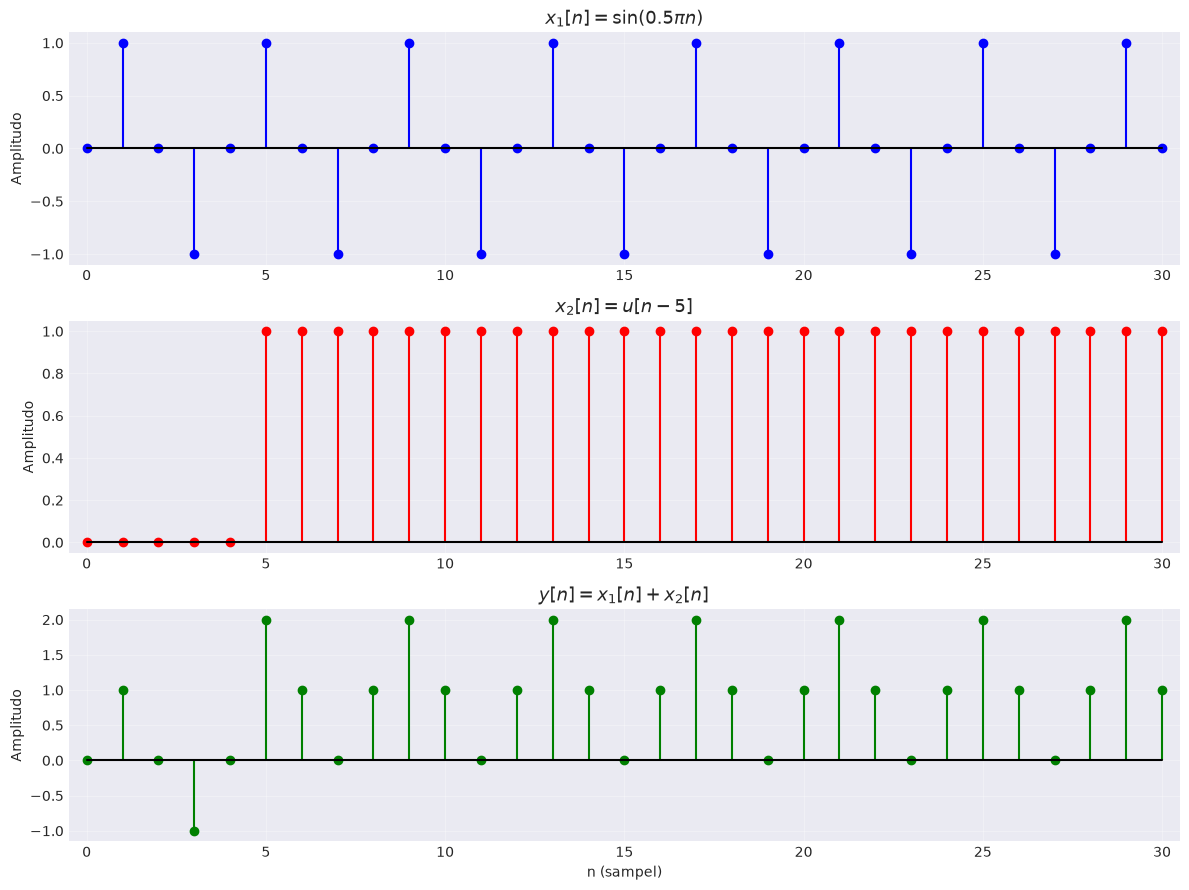

In [3]:
y = x1 + x2
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9))
ax1.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='k-'); ax1.set_title(r'$x_1[n] = \sin(0.5\pi n)$', fontsize=13, fontweight='bold'); ax1.set_ylabel('Amplitudo'); ax1.grid(True, alpha=0.3); ax1.set_xlim(-0.5, 30.5)
ax2.stem(n, x2, linefmt='r-', markerfmt='ro', basefmt='k-'); ax2.set_title(r'$x_2[n] = u[n-5]$', fontsize=13, fontweight='bold'); ax2.set_ylabel('Amplitudo'); ax2.grid(True, alpha=0.3); ax2.set_xlim(-0.5, 30.5)
ax3.stem(n, y, linefmt='g-', markerfmt='go', basefmt='k-'); ax3.set_title(r'$y[n] = x_1[n] + x_2[n]$', fontsize=13, fontweight='bold'); ax3.set_xlabel('n (sampel)'); ax3.set_ylabel('Amplitudo'); ax3.grid(True, alpha=0.3); ax3.set_xlim(-0.5, 30.5)
plt.tight_layout(); plt.savefig('images/penjumlahan_sinyal.png', dpi=100, bbox_inches='tight'); plt.show()

**Analisis:**  
- n<5: y[n] = x1[n] (x2=0)  
- n>=5: y[n] = x1[n]+1 → DC offset +1  
- Bentuk sinusoidal tetap tampak  

**1. Perubahan amplitudo:** Meningkat (max jadi 2).  
**2. Menyerupai sinyal asal?** Ya, lebih mirip x1 dengan DC shift.  
**3. Aplikasi nyata:** Audio mixing, sensor fusion, noise cancellation, image blending.

## A.3 Operasi Penggeseran Sinyal
**Operasi:** $y[n] = x[n - k]$ dengan k = -3, 0, 4

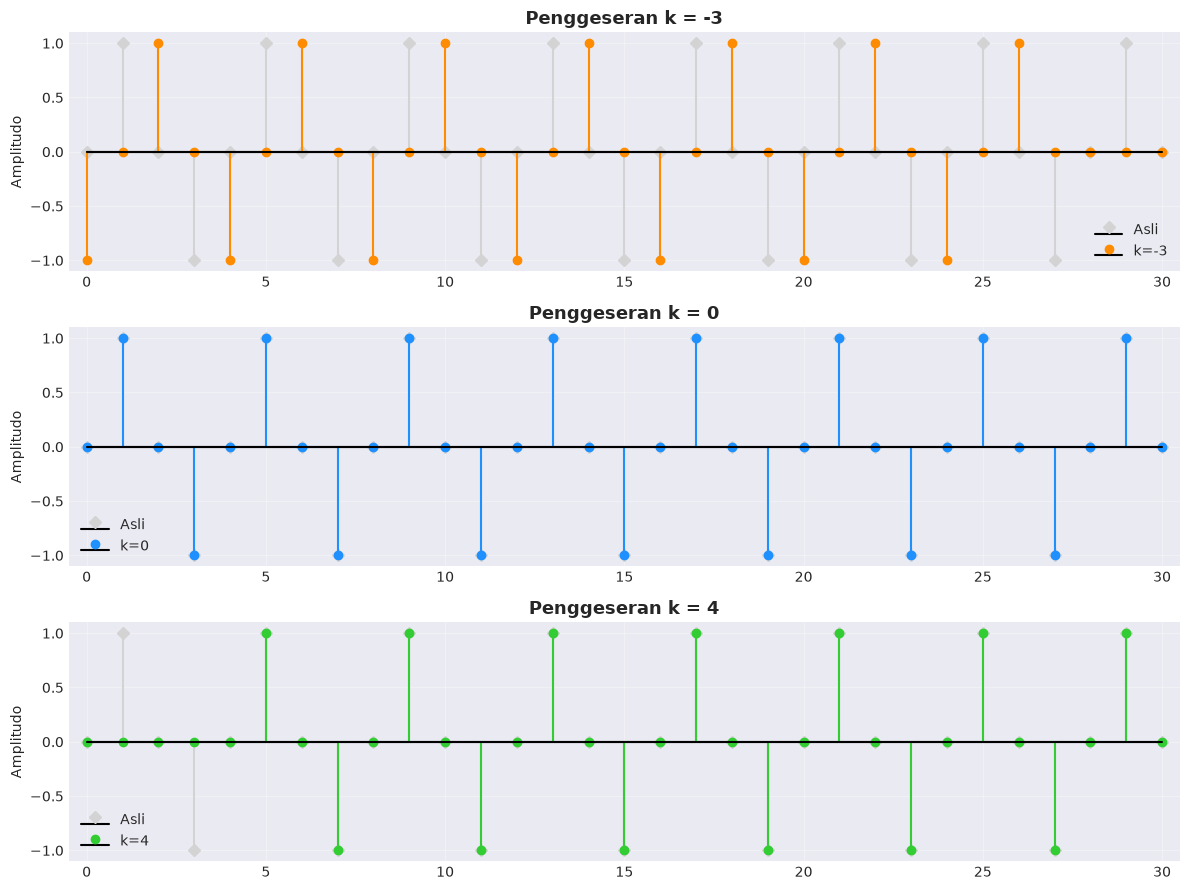

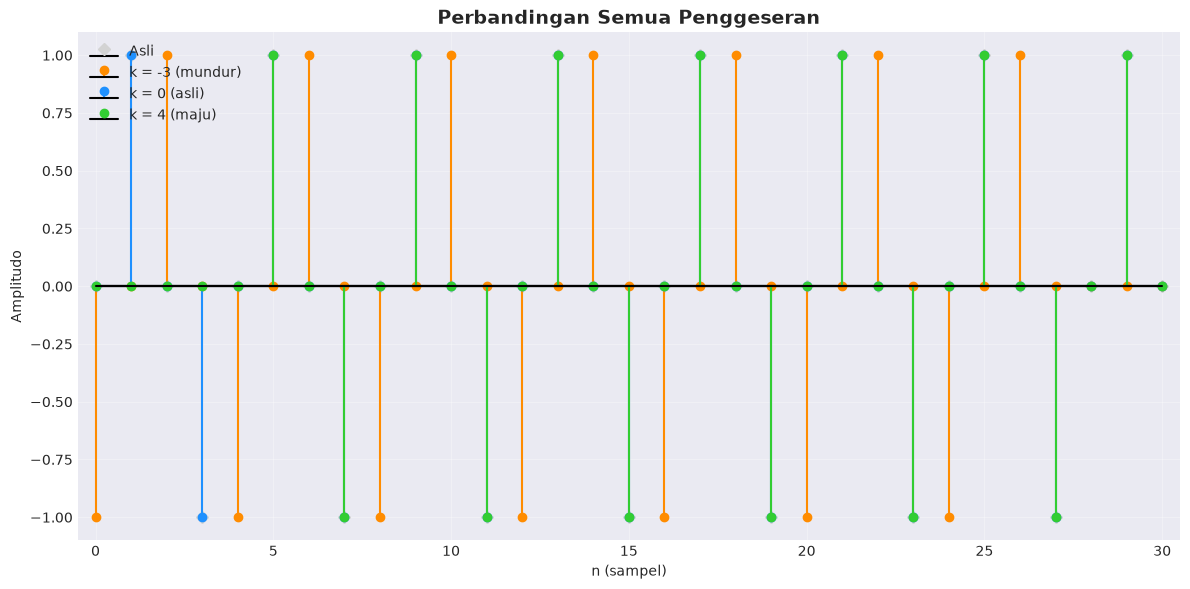

In [4]:
x = x1.copy()
k_vals = [-3, 0, 4]
clrs = ['#FF8C00', '#1E90FF', '#32CD32']
lbls = ['k = -3 (mundur)', 'k = 0 (asli)', 'k = 4 (maju)']

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for idx, (k, ax) in enumerate(zip(k_vals, axes)):
    yk = np.roll(x, k)
    if k > 0: yk[:k] = 0
    elif k < 0: yk[k:] = 0
    ax.stem(n, x, linefmt='lightgray', markerfmt='D', basefmt='k-', label='Asli')
    m, s, b = ax.stem(n, yk, linefmt='gray', markerfmt='o', basefmt='k-', label=f'k={k}')
    plt.setp(m, 'color', clrs[idx]); plt.setp(s, 'color', clrs[idx])
    ax.set_title(f'Penggeseran k = {k}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Amplitudo'); ax.grid(True, alpha=0.3); ax.legend(); ax.set_xlim(-0.5, 30.5)
plt.tight_layout(); plt.savefig('images/penggeseran_sinyal.png', dpi=100, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.stem(n, x, linefmt='lightgray', markerfmt='D', basefmt='k-', label='Asli')
for idx, (k, c, lb) in enumerate(zip(k_vals, clrs, lbls)):
    yk = np.roll(x, k)
    if k > 0: yk[:k] = 0
    elif k < 0: yk[k:] = 0
    m, s, b = ax.stem(n, yk, linefmt='gray', markerfmt='o', basefmt='k-', label=lb)
    plt.setp(m, 'color', c); plt.setp(s, 'color', c)
ax.set_title('Perbandingan Semua Penggeseran', fontsize=14, fontweight='bold')
ax.set_xlabel('n (sampel)'); ax.set_ylabel('Amplitudo'); ax.grid(True, alpha=0.3); ax.legend(); ax.set_xlim(-0.5, 30.5)
plt.tight_layout(); plt.savefig('images/penggeseran_sinyal_komparasi.png', dpi=100, bbox_inches='tight'); plt.show()

**Pertanyaan:**  
**1. Efek k positif vs negatif?** k=+ → delay (kanan); k=- → advance (kiri).  
**2. Simulasi delay?** y[n]=x[n-k]; sampling 44.1kHz, k=44100 → delay 1 detik.  
**3. Time alignment?** Menyelaraskan sinyal dari sumber berbeda agar fase tidak cancel.

## A.4 Operasi Amplifikasi Sinyal
**Operasi:** $y[n] = lpha \cdot x[n]$ dengan α = 0.5, 1, 2, -1

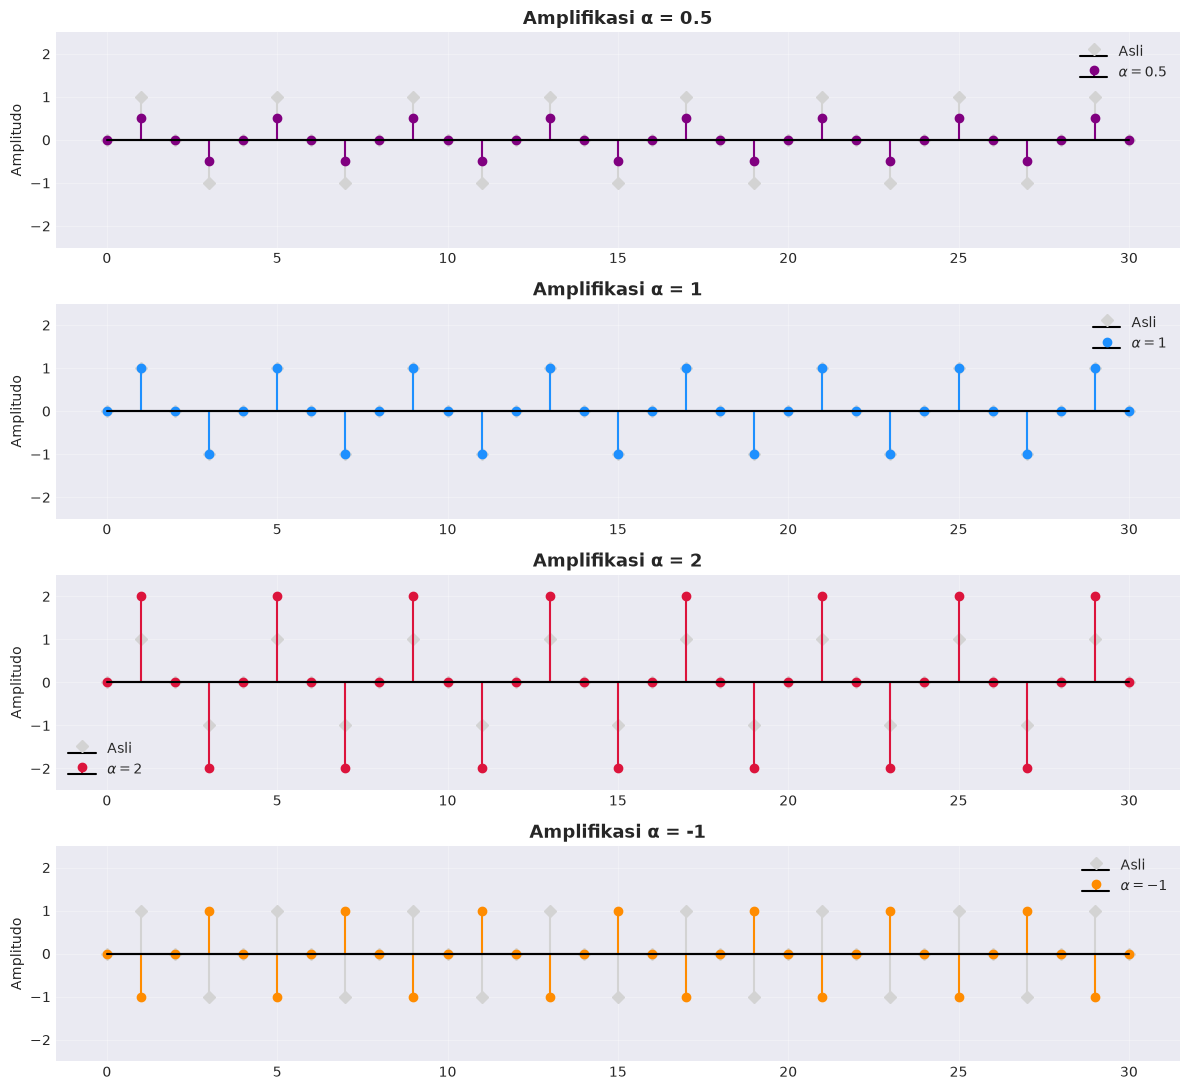

In [5]:
x = x1.copy()
alphas = [0.5, 1, 2, -1]
clrs = ['#800080', '#1E90FF', '#DC143C', '#FF8C00']

fig, axes = plt.subplots(4, 1, figsize=(12, 11))
for idx, (a, ax) in enumerate(zip(alphas, axes)):
    y = a * x
    ax.stem(n, x, linefmt='lightgray', markerfmt='D', basefmt='k-', label='Asli')
    m, s, b = ax.stem(n, y, linefmt='gray', markerfmt='o', basefmt='k-', label=fr'$\alpha={a}$')
    plt.setp(m, 'color', clrs[idx]); plt.setp(s, 'color', clrs[idx])
    ax.set_title(f'Amplifikasi α = {a}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Amplitudo'); ax.grid(True, alpha=0.3); ax.legend(); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.savefig('images/amplifikasi_sinyal.png', dpi=100, bbox_inches='tight'); plt.show()

**Tabel Efek α:**  

| α | Efek |
|:---:|---|
| 0.5 | Atenuasi 50% |
| 1 | Sama dengan asli |
| 2 | Amplifikasi 2× |
| -1 | Inversi fasa 180° |

**1. α>1?** Diperkuat, risiko clipping.  
**2. 0<α<1?** Diperlemah (volume control).  
**3. α negatif?** Inversi fasa (dasar noise cancellation).  
**4. Hubungan dgn gain audio?** Gain = α; dinyatakan dB: $G_{dB}=20\log_{10}(lpha)$.

---
# Bagian B: Operasi pada Citra 2D


## B.1 Membaca dan Menampilkan Citra

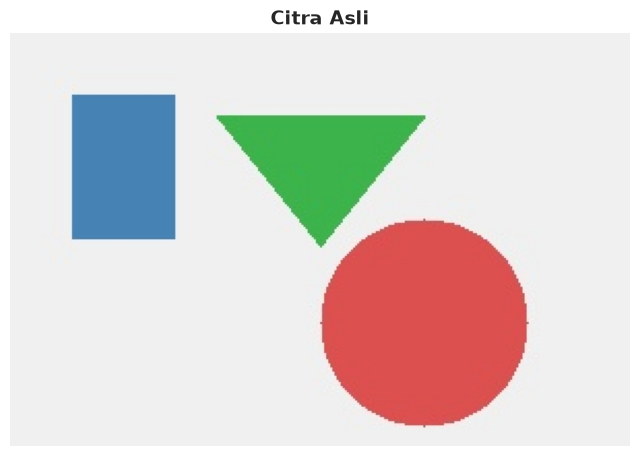

Ukuran: (200, 300, 3)
Tipe data: uint8
Min pixel: 52
Max pixel: 255


In [6]:
img = cv2.imread('images/citra_asli.jpg')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6)); plt.imshow(rgb); plt.title('Citra Asli', fontsize=14, fontweight='bold'); plt.axis('off')
plt.savefig('images/citra_asli_tampil.png', dpi=100, bbox_inches='tight'); plt.show()
print(f"Ukuran: {img.shape}\nTipe data: {img.dtype}\nMin pixel: {img.min()}\nMax pixel: {img.max()}")

## B.2 Operasi Penjumlahan Citra
**Operasi:** $I(i,j) = I_1(i,j) + I_2(i,j)$

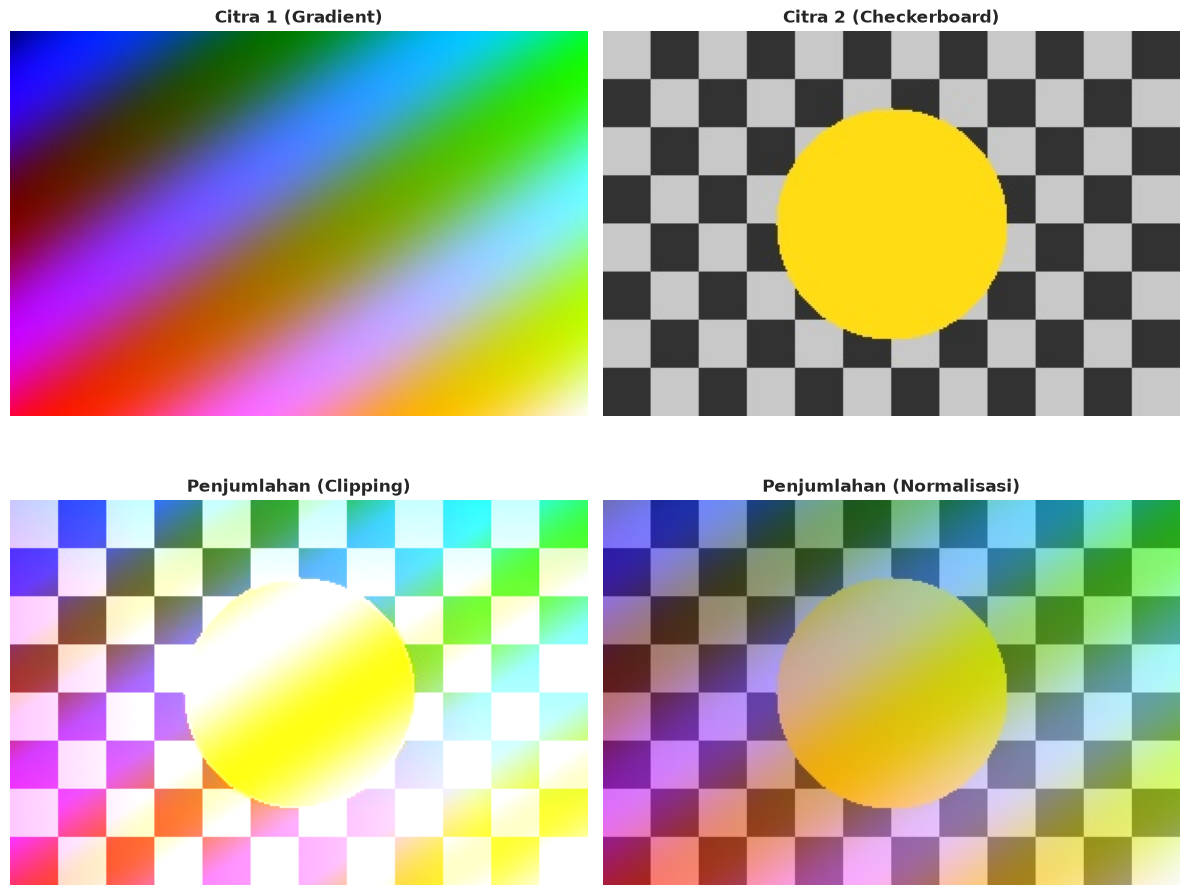

In [7]:
i1 = cv2.imread('images/citra1.jpg'); i2 = cv2.imread('images/citra2.jpg')
if i1.shape != i2.shape:
    i2 = cv2.resize(i2, (i1.shape[1], i1.shape[0]))
i1r = cv2.cvtColor(i1, cv2.COLOR_BGR2RGB); i2r = cv2.cvtColor(i2, cv2.COLOR_BGR2RGB)

# Clipping
sc = cv2.add(i1, i2); scr = cv2.cvtColor(sc, cv2.COLOR_BGR2RGB)
# Normalisasi
sf = i1.astype(np.float32) + i2.astype(np.float32)
sn = (sf / sf.max() * 255).astype(np.uint8); snr = cv2.cvtColor(sn, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0,0].imshow(i1r); ax[0,0].set_title('Citra 1 (Gradient)', fontweight='bold'); ax[0,0].axis('off')
ax[0,1].imshow(i2r); ax[0,1].set_title('Citra 2 (Checkerboard)', fontweight='bold'); ax[0,1].axis('off')
ax[1,0].imshow(scr); ax[1,0].set_title('Penjumlahan (Clipping)', fontweight='bold'); ax[1,0].axis('off')
ax[1,1].imshow(snr); ax[1,1].set_title('Penjumlahan (Normalisasi)', fontweight='bold'); ax[1,1].axis('off')
plt.tight_layout(); plt.savefig('images/penjumlahan_citra.png', dpi=100, bbox_inches='tight'); plt.show()

**Analisis:** Clipping: detail terang hilang (saturasi). Normalisasi: detail terjaga namun kontras berkurang.  

**1. Ukuran harus sama?** Operasi element-wise perlu padanan pixel.  
**2. Melebihi max?** Clip ke 255, hilang informasi.  
**3. Clipping vs normalisasi?** Clipping kontras tinggi tapi detail hilang; normalisasi sebaliknya.  
**4. Aplikasi:** Image blending, long exposure, medical fusion, augmentasi.

## B.3 Operasi Penggeseran Citra
$I'(i,j) = I(i-\Delta i, j-\Delta j)$ — Δi=30,Δj=0 | Δi=0,Δj=30 | Δi=30,Δj=30

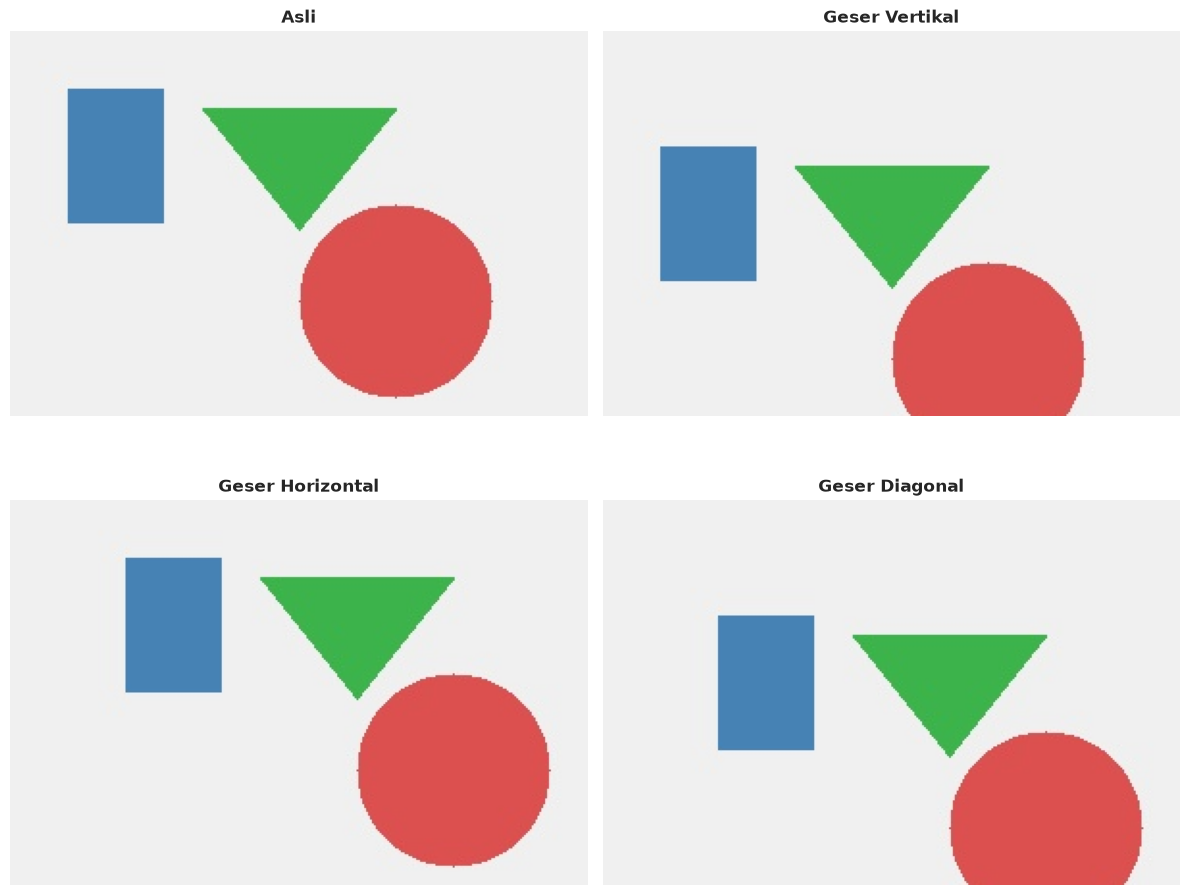

In [8]:
img = cv2.imread('images/citra_asli.jpg'); rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
shifts = [(30,0,'Vertikal'), (0,30,'Horizontal'), (30,30,'Diagonal')]
fig, ax = plt.subplots(2,2,figsize=(12,10))
ax[0,0].imshow(rgb); ax[0,0].set_title('Asli',fontweight='bold'); ax[0,0].axis('off')
for idx,(di,dj,t) in enumerate(shifts):
    M = np.float32([[1,0,dj],[0,1,di]])
    s = cv2.warpAffine(img,M,(w,h),borderValue=(240,240,240))
    sr = cv2.cvtColor(s,cv2.COLOR_BGR2RGB)
    r,c = (idx+1)//2, (idx+1)%2
    ax[r,c].imshow(sr); ax[r,c].set_title(f'Geser {t}',fontweight='bold'); ax[r,c].axis('off')
plt.tight_layout(); plt.savefig('images/penggeseran_citra.png',dpi=100,bbox_inches='tight'); plt.show()

**Area kosong:** Muncul di sisi berlawanan, diisi latar abu-abu (240).  

**1. Efek terhadap objek?** Posisi berubah, bentuk/ukuran tetap.  
**2. Augmentasi data?** Model jadi shift-invariant.  
**3. Risiko geser terlalu besar?** Objek keluar frame.

## B.4 Operasi Amplifikasi Citra
$I'(i,j) = lpha \cdot I(i,j)$ — α = 0.5, 1.0, 1.5, 2.0

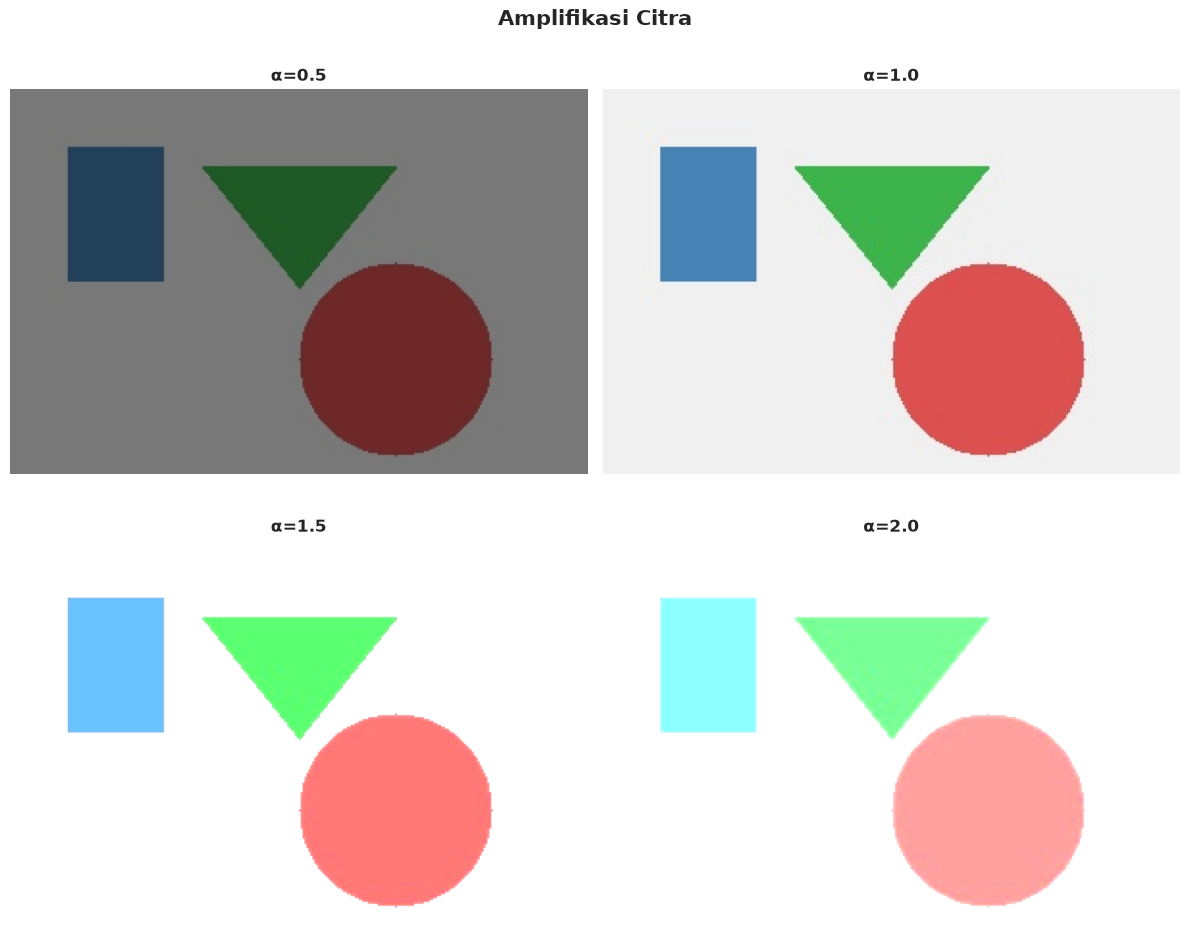

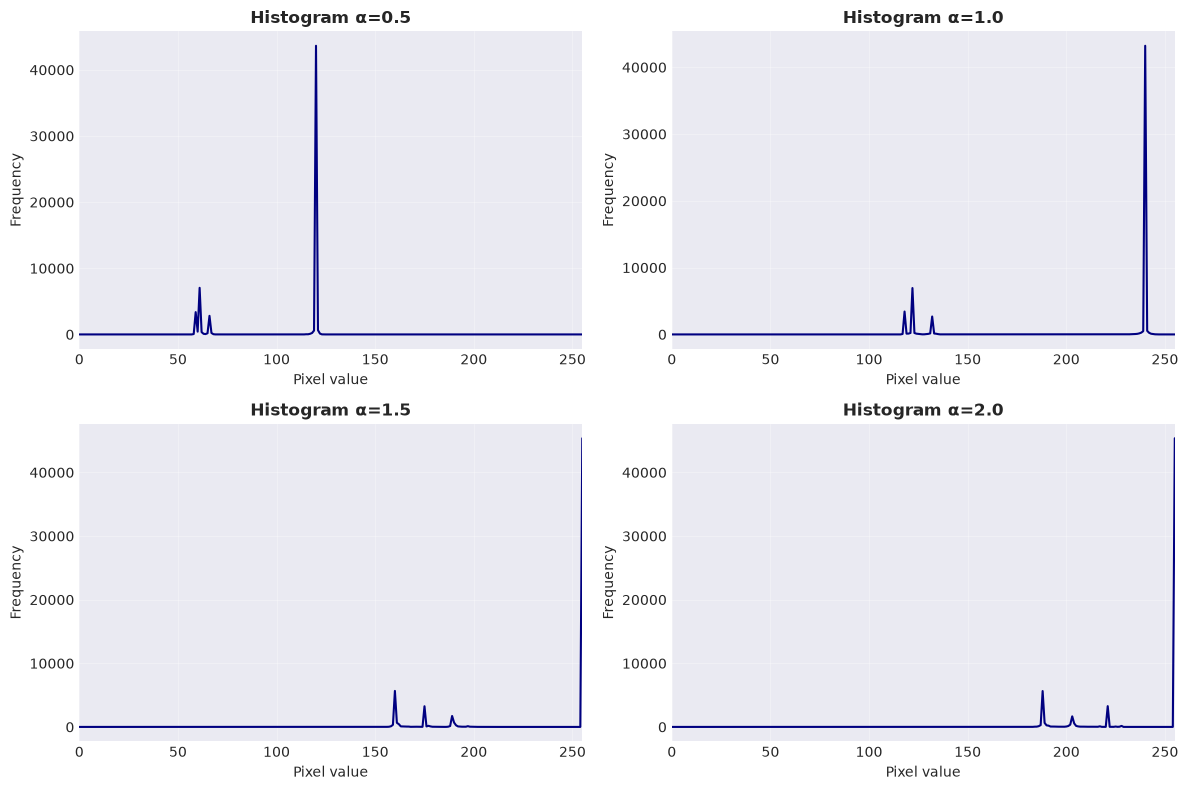

In [9]:
img = cv2.imread('images/citra_asli.jpg'); rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
alphas = [0.5, 1.0, 1.5, 2.0]
fig, ax = plt.subplots(2,2,figsize=(12,10))
for idx,a in enumerate(alphas):
    amp = cv2.convertScaleAbs(img,alpha=a,beta=0); ar = cv2.cvtColor(amp,cv2.COLOR_BGR2RGB)
    r,c = idx//2,idx%2; ax[r,c].imshow(ar); ax[r,c].set_title(f'α={a}',fontweight='bold'); ax[r,c].axis('off')
plt.suptitle('Amplifikasi Citra',fontsize=15,fontweight='bold'); plt.tight_layout()
plt.savefig('images/amplifikasi_citra.png',dpi=100,bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(2,2,figsize=(12,8))
for idx,a in enumerate(alphas):
    amp = cv2.convertScaleAbs(img,alpha=a,beta=0)
    gry = cv2.cvtColor(amp,cv2.COLOR_BGR2GRAY); hist = cv2.calcHist([gry],[0],None,[256],[0,256])
    r,c = idx//2,idx%2; ax[r,c].plot(hist,color='navy'); ax[r,c].set_title(f'Histogram α={a}',fontweight='bold')
    ax[r,c].set_xlabel('Pixel value'); ax[r,c].set_ylabel('Frequency'); ax[r,c].grid(True,alpha=0.3); ax[r,c].set_xlim(0,255)
plt.tight_layout(); plt.savefig('images/histogram_amplifikasi.png',dpi=100,bbox_inches='tight'); plt.show()

| α | Brightness | Kontras | Efek Visual |
|:---:|:---:|:---:|---|
| 0.5 | Turun | Turun | Gelap |
| 1.0 | Normal | Normal | Asli |
| 1.5 | Naik | Naik | Lebih terang |
| 2.0 | Sangat naik | Saturasi | Putih (detail hilang) |

**1. α>1?** Brightness naik, >255 di-clip.  
**2. 0<α<1?** Brightness turun.  
**3. Pixel perlu dibatasi?** uint8 0-255, di luar itu artifacts.  
**4. Hubungan brightness?** Amplifikasi = exposure + brightness.

---
# Bagian C: Uji Sistem Linier
Syarat sistem linier: ① Homogenitas $T(lpha x) = lpha T(x)$  ② Additivitas $T(x_1+x_2) = T(x_1)+T(x_2)$

## C.1 Uji Homogenitas
**Sistem:** $T(x) = 2x$

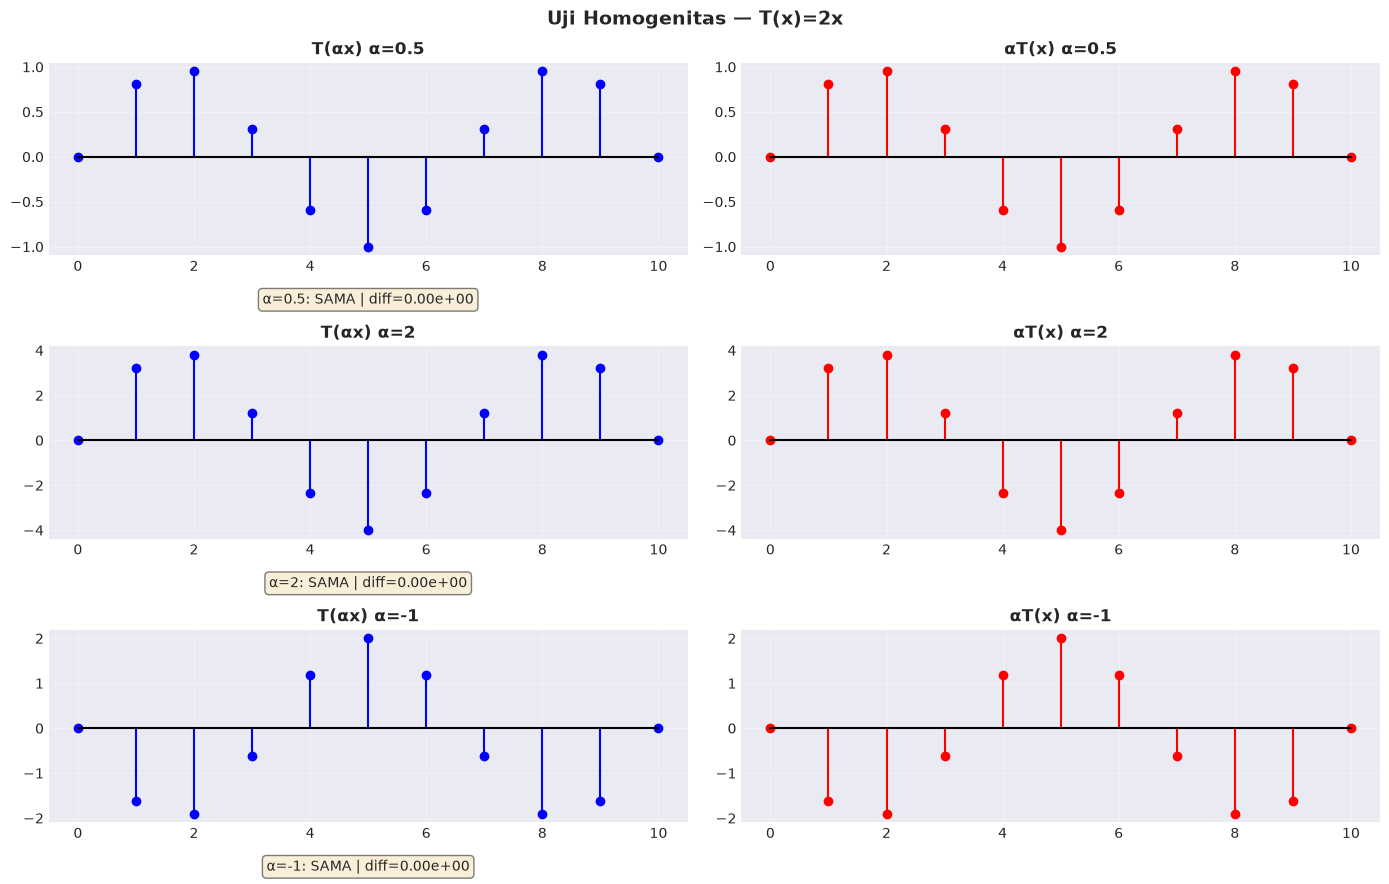

Kesimpulan: T(x)=2x MEMENUHI homogenitas.


In [10]:
def T(x): return 2*x

n = np.arange(0, 11); x = np.sin(0.3 * np.pi * n)
alphas = [0.5, 2, -1]
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for idx, a in enumerate(alphas):
    Ta = T(a*x); aT = a*T(x)
    axes[idx,0].stem(n, Ta, linefmt='b-', markerfmt='bo', basefmt='k-')
    axes[idx,0].set_title(f'T(αx) α={a}', fontweight='bold'); axes[idx,0].grid(True, alpha=0.3)
    axes[idx,1].stem(n, aT, linefmt='r-', markerfmt='ro', basefmt='k-')
    axes[idx,1].set_title(f'αT(x) α={a}', fontweight='bold'); axes[idx,1].grid(True, alpha=0.3)
    d = np.max(np.abs(Ta-aT))
    axes[idx,0].text(0.5,-0.25,f'α={a}: {"SAMA" if d<1e-10 else "BEDA"} | diff={d:.2e}', ha='center',
                     transform=axes[idx,0].transAxes, bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
plt.suptitle('Uji Homogenitas — T(x)=2x', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('images/homogenitas.png',dpi=100,bbox_inches='tight'); plt.show()
print("Kesimpulan: T(x)=2x MEMENUHI homogenitas.")

## C.2 Uji Additivitas
**Sistem:** $T(x) = 2x$

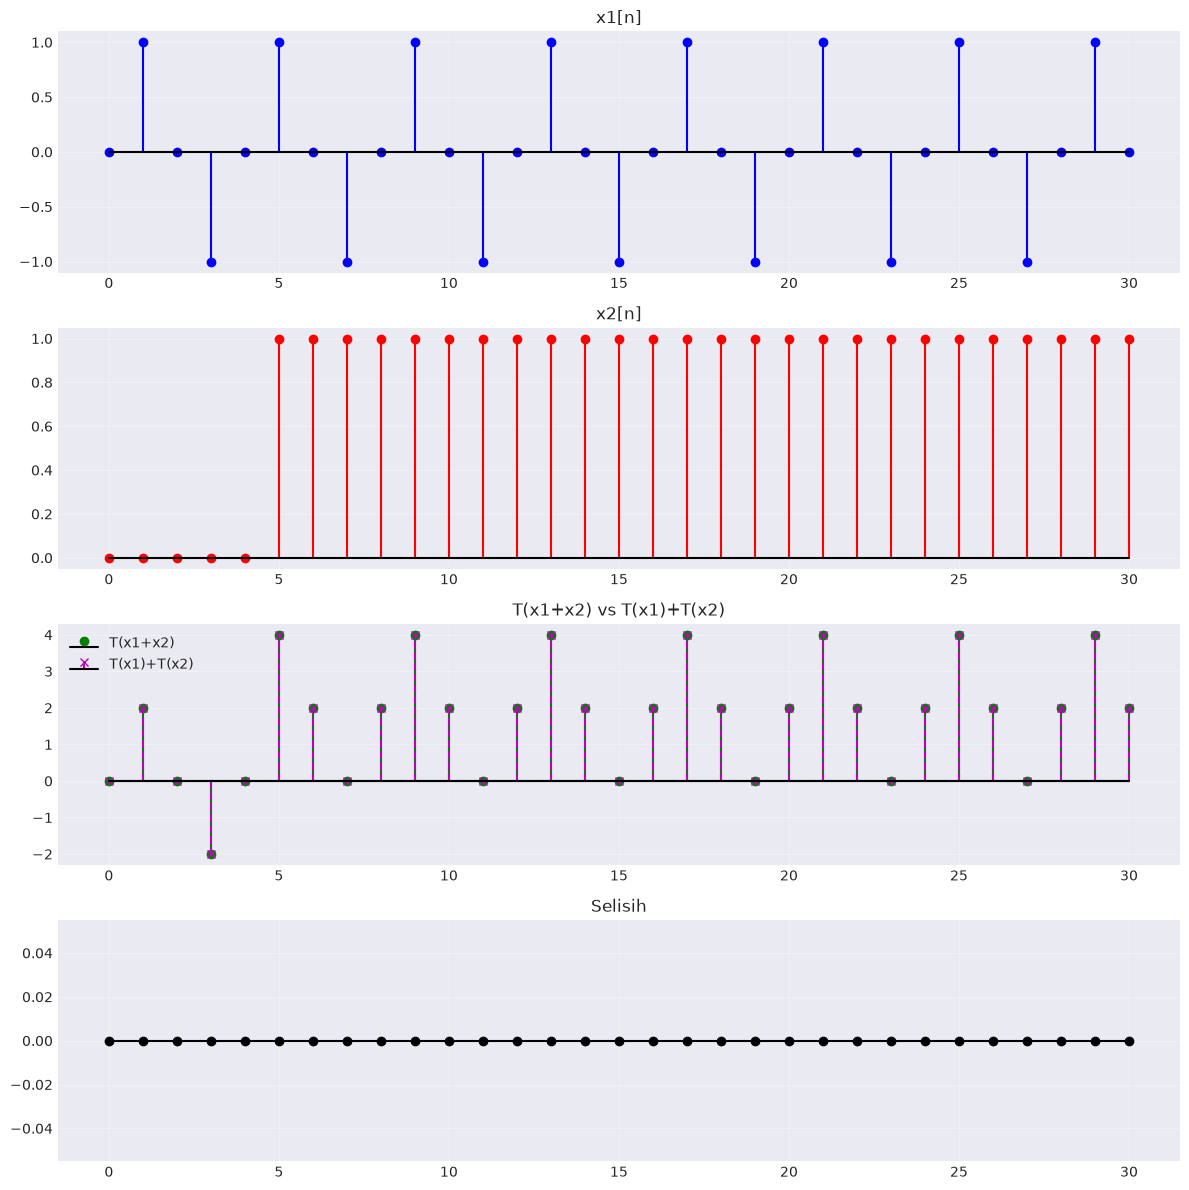

Selisih max: 0.00e+00
Sistem T(x)=2x MEMENUHI additivitas.


In [11]:
n = np.arange(0,31); x1 = np.sin(0.5*np.pi*n); x2 = np.where(n>=5,1,0)
Tx1x2 = T(x1+x2); Tx1Tx2 = T(x1)+T(x2); diff = Tx1x2 - Tx1Tx2
fig, axes = plt.subplots(4,1,figsize=(12,12))
axes[0].stem(n,x1,linefmt='b-',markerfmt='bo',basefmt='k-'); axes[0].set_title('x1[n]'); axes[0].grid(True,alpha=0.3)
axes[1].stem(n,x2,linefmt='r-',markerfmt='ro',basefmt='k-'); axes[1].set_title('x2[n]'); axes[1].grid(True,alpha=0.3)
axes[2].stem(n,Tx1x2,linefmt='g-',markerfmt='go',basefmt='k-',label='T(x1+x2)')
axes[2].stem(n,Tx1Tx2,linefmt='m--',markerfmt='mx',basefmt='k-',label='T(x1)+T(x2)')
axes[2].set_title('T(x1+x2) vs T(x1)+T(x2)'); axes[2].grid(True,alpha=0.3); axes[2].legend()
axes[3].stem(n,diff,linefmt='k-',markerfmt='ko',basefmt='k-'); axes[3].set_title('Selisih'); axes[3].grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('images/additivitas.png',dpi=100,bbox_inches='tight'); plt.show()
md = np.max(np.abs(diff))
print(f"Selisih max: {md:.2e}\nSistem T(x)=2x MEMENUHI additivitas.")

## C.3 Perbandingan Sistem Linier dan Non-Linier  
$T_1(x) = 2x$ (linier) vs $T_2(x) = x^2$ (non-linier)

UJI HOMOGENITAS
T1(x)=2x: YA (diff=0.00e+00)
T2(x)=x²: TIDAK (diff=2.00e+00)

UJI ADDITIVITAS
T1(x)=2x: YA (diff=0.00e+00)
T2(x)=x²: TIDAK (diff=2.00e+00)


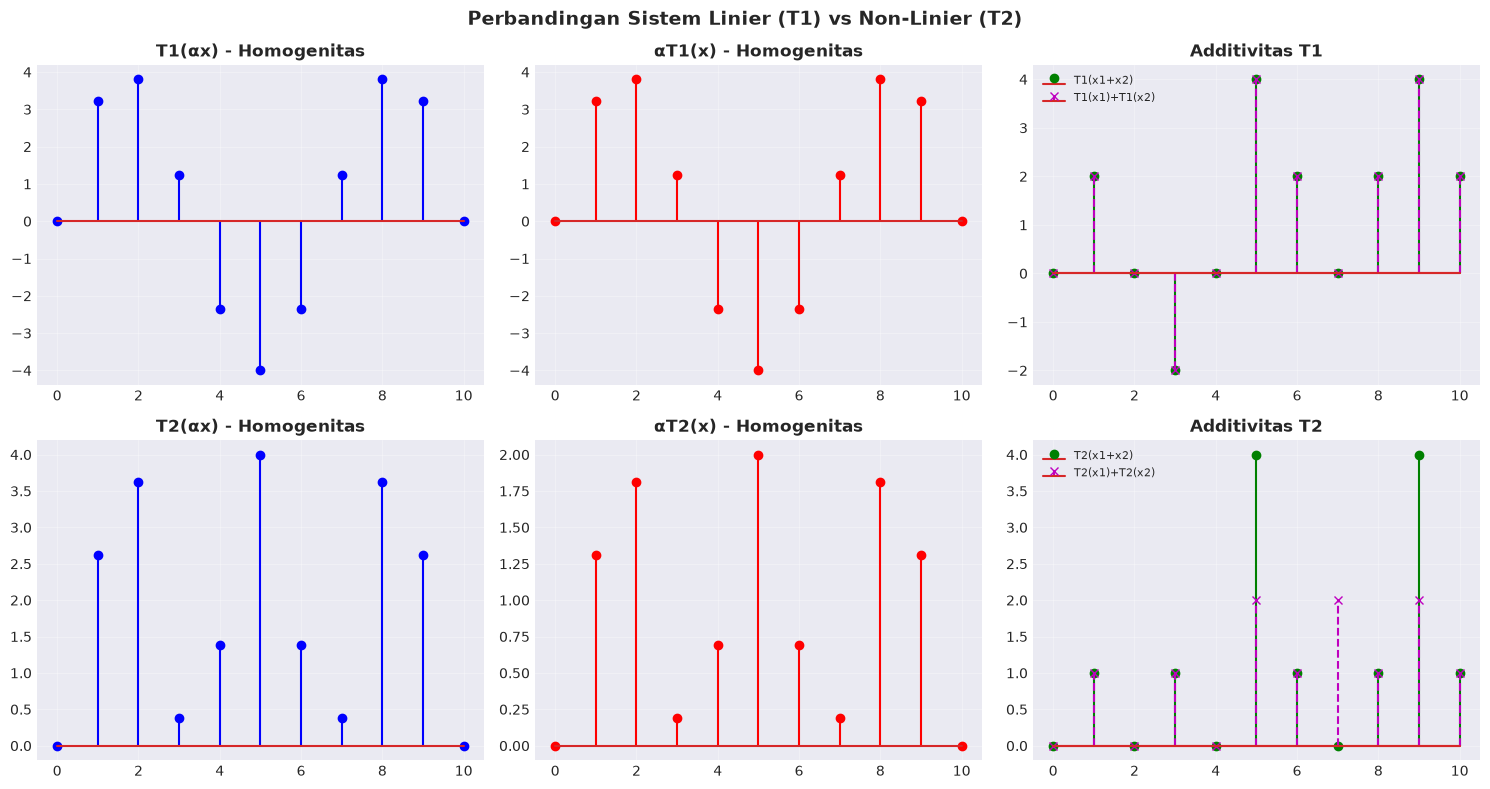

In [12]:
def T1(x): return 2*x
def T2(x): return x**2

n = np.arange(0,11); x = np.sin(0.3*np.pi*n); x1 = np.sin(0.5*np.pi*n); x2 = np.where(n>=5,1,0); a = 2

print("="*50+"\nUJI HOMOGENITAS\n"+"="*50)
for name,fn in [("T1(x)=2x",T1),("T2(x)=x²",T2)]:
    d = np.max(np.abs(fn(a*x) - a*fn(x)))
    print(f"{name}: {'YA' if d<1e-10 else 'TIDAK'} (diff={d:.2e})")
print("\n"+"="*50+"\nUJI ADDITIVITAS\n"+"="*50)
for name,fn in [("T1(x)=2x",T1),("T2(x)=x²",T2)]:
    d = np.max(np.abs(fn(x1+x2) - (fn(x1)+fn(x2))))
    print(f"{name}: {'YA' if d<1e-10 else 'TIDAK'} (diff={d:.2e})")

fig, axes = plt.subplots(2,3,figsize=(15,8))
# T1
axes[0,0].stem(n,T1(a*x),linefmt='b-',markerfmt='bo'); axes[0,0].set_title('T1(αx) - Homogenitas',fontweight='bold'); axes[0,0].grid(True,alpha=0.3)
axes[0,1].stem(n,a*T1(x),linefmt='r-',markerfmt='ro'); axes[0,1].set_title('αT1(x) - Homogenitas',fontweight='bold'); axes[0,1].grid(True,alpha=0.3)
axes[0,2].stem(n,T1(x1+x2),linefmt='g-',markerfmt='go',label='T1(x1+x2)')
axes[0,2].stem(n,T1(x1)+T1(x2),linefmt='m--',markerfmt='mx',label='T1(x1)+T1(x2)')
axes[0,2].set_title('Additivitas T1',fontweight='bold'); axes[0,2].grid(True,alpha=0.3); axes[0,2].legend(fontsize=8)
# T2
axes[1,0].stem(n,T2(a*x),linefmt='b-',markerfmt='bo'); axes[1,0].set_title('T2(αx) - Homogenitas',fontweight='bold'); axes[1,0].grid(True,alpha=0.3)
axes[1,1].stem(n,a*T2(x),linefmt='r-',markerfmt='ro'); axes[1,1].set_title('αT2(x) - Homogenitas',fontweight='bold'); axes[1,1].grid(True,alpha=0.3)
axes[1,2].stem(n,T2(x1+x2),linefmt='g-',markerfmt='go',label='T2(x1+x2)')
axes[1,2].stem(n,T2(x1)+T2(x2),linefmt='m--',markerfmt='mx',label='T2(x1)+T2(x2)')
axes[1,2].set_title('Additivitas T2',fontweight='bold'); axes[1,2].grid(True,alpha=0.3); axes[1,2].legend(fontsize=8)
plt.suptitle('Perbandingan Sistem Linier (T1) vs Non-Linier (T2)',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('images/perbandingan_sistem.png',dpi=100,bbox_inches='tight'); plt.show()

**Tabel Perbandingan:**  

| Sistem | Homogenitas | Additivitas | Linier? |
|:---:|:---:|:---:|:---:|
| $T_1(x)=2x$ | ✓ | ✓ | **Linier** |
| $T_2(x)=x^2$ | ✗ | ✗ | **Non-linier** |

**1. T1 linier?** $T(lpha x_1+eta x_2) = 2(lpha x_1+eta x_2) = lpha\cdot2x_1+eta\cdot2x_2$  
**2. T2 non-linier?** $(lpha x)^2 = lpha^2 x^2 
eq lpha\cdot x^2$ dan $(x_1+x_2)^2 = x_1^2+2x_1x_2+x_2^2$  
**3. Mengapa penting?** Superposisi, analisis Fourier, perancangan filter.  
**4. Hubungan dgn superposisi?** Superposisi = esensi linieritas.

---
# Bagian D: Analisis HOTS


## D.1 Analisis Konseptual  

**1. Mengapa penjumlahan & amplifikasi jadi dasar superposisi?**  
Kombinasi linear terdiri dari amplifikasi (α,β) dan penjumlahan (+). Superposisi = output kombinasi linear = kombinasi linear output.

**2. Kenapa tidak semua operasi linier?** Operasi harus memenuhi homogenitas & additivitas. Contoh gagal: $x^2$, $\sin(x)$, thresholding.

**3. Dampak sistem non-linier?** Harmonik baru, intermodulasi, distorsi, superposisi tidak berlaku.

**4. Kenapa shift & amplify penting?** Shift = delay, echo, motion estimation. Amplify = volume, brightness, gain. Blok fundamental DSP.

## D.2 Studi Kasus: Audio Mixing  
**Masalah:** Mencampur track audio. **Operasi:** Penjumlahan (mixing), amplifikasi (gain), penggeseran (delay/spatial).  
**Linieritas:** Mixing dasar linier; praktik nyata punya kompresor (non-linier).  
**Kelebihan:** Sederhana, O(N), predictable. **Kekurangan:** Tidak model saturasi/noise masking.

## D.3 Skenario Keputusan  

**S1:** Dua citra ukuran berbeda → resize dulu. Alasan: operasi element-wise.  
**S2:** Audio terlalu kecil → amplifikasi α>1. Risiko: clipping → distorsi.  
**S3:** Deteksi objek gagal → translasi augmentasi data. Model jadi shift-invariant.  
**S4:** Output beda saat urutan ditukar → sistem non-linier (LTI bersifat komutatif).

---
# Kesimpulan & Refleksi  

| Operasi | Sinyal 1D | Citra 2D |
|:---:|:---:|:---:|
| Penjumlahan | Superposisi amplitudo | Image blending |
| Penggeseran | Time delay/advance | Translasi objek |
| Amplifikasi | Gain/volume | Brightness/contrast |
| Uji Linieritas | Homogenitas+Additivitas | — |

**1. Termudah:** Amplifikasi (intuitif).  
**2. Tersulit:** Penggeseran dengan zero-padding.  
**3. Perbedaan 1D vs 2D:** Citra punya 2 dimensi + 3 channel.  
**4. Insight baru:** $x^2$ saja sudah cukup mematahkan linieritas.  
**5. Paling penting:** Superposisi & linieritas — dasar filtering, kompresi, analisis spektrum.
